# 1.1

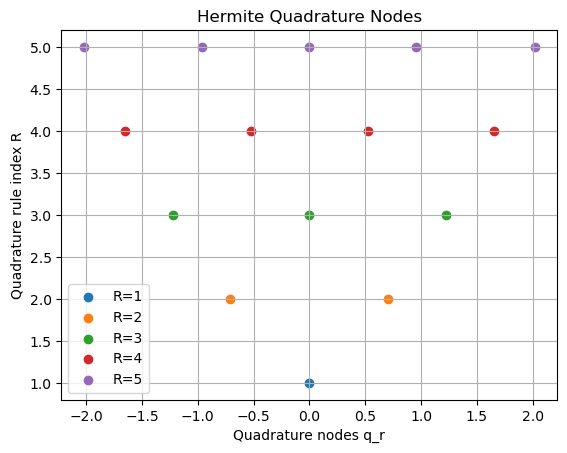

Weights for R = 4 (from left to right)
-----------------
Node 1: weight = 0.0458758547680685
Node 2: weight = 0.4541241452319315
Node 3: weight = 0.4541241452319315
Node 4: weight = 0.0458758547680685


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss

# problem parameters
t = 1
u0 = 1
def u(Q):
    return u0*np.exp(-Q*t)  

# analytic solutions (Appendix A)
true_mean = np.exp(0.5)
true_var = np.exp(2) - np.exp(1)



############################################################
# 1.1 Plot Hermite quadrature nodes
############################################################

plt.figure()

for R in range(1,6):

    nodes, weights = hermgauss(R)

    plt.scatter(nodes, [R]*len(nodes), label=f"R={R}")

plt.xlabel("Quadrature nodes q_r")
plt.ylabel("Quadrature rule index R")
plt.title("Hermite Quadrature Nodes")
plt.grid()
plt.legend()

plt.show()


############################################################
# Table of weights for R = 4
############################################################

R = 4
nodes4, weights4 = hermgauss(R)

weights4 = weights4/np.sqrt(np.pi)

print("Weights for R = 4 (from left to right)")
print("-----------------")

for i in range(R):
    print(f"Node {i+1}: weight = {weights4[i]}")



# 1.2

In [5]:

############################################################
# 1.2 Mean and variance with R = 10
############################################################

R = 10
nodes, weights = hermgauss(R)

weights = weights/np.sqrt(np.pi)

mean_quad = np.sum(weights * u(np.sqrt(2)*nodes))

second_moment = np.sum(weights * (u(np.sqrt(2)*nodes)**2))
var_quad = second_moment - mean_quad**2

print("\nApproximate mean (R=10):", mean_quad)
print("Approximate variance (R=10):", var_quad)





Approximate mean (R=10): 1.6487212706982322
Approximate variance (R=10): 4.67077017863374


# 1.3

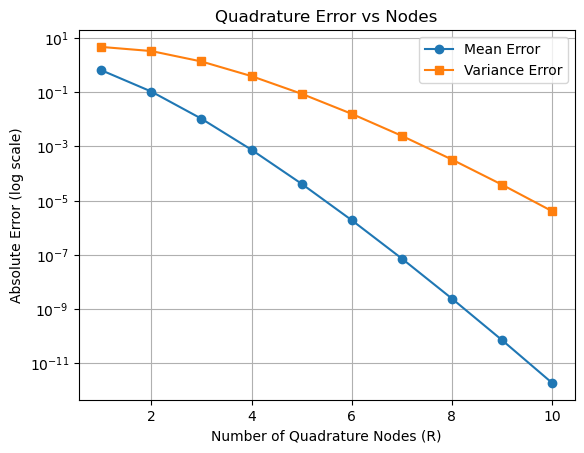

In [6]:
############################################################
# 1.3 Error vs number of nodes
############################################################

mean_error = []
var_error = []
R_vals = np.arange(1,11)

for R in R_vals:

    nodes, weights = hermgauss(R)

    weights = weights/np.sqrt(np.pi)
    mean_quad = np.sum(weights * u(np.sqrt(2)*nodes))
    second_moment = np.sum(weights * (u(np.sqrt(2)*nodes)**2))

    var_quad = second_moment - mean_quad**2

    mean_error.append(abs(mean_quad - true_mean))
    var_error.append(abs(var_quad - true_var))


############################################################
# Plot error
############################################################

plt.figure()

plt.plot(R_vals, mean_error, marker='o', label="Mean Error")
plt.plot(R_vals, var_error, marker='s', label="Variance Error")

plt.yscale("log")

plt.xlabel("Number of Quadrature Nodes (R)")
plt.ylabel("Absolute Error (log scale)")
plt.title("Quadrature Error vs Nodes")

plt.grid()
plt.legend()

plt.show()